In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from sympy import N
from sympy.physics.wigner import clebsch_gordan

In [4]:
x=np.linspace(2.00001,20,1000)

In [5]:
def f(r):
    return 1-2*M/r
def V(x,l,mu):
    return f(x)*(l*(l+1)/x**2+2*M/x**3+mu**2)
def rstar(r):
    return r + 2*M*np.log(r/(2*M)-1)

In [6]:
M=1
xs=rstar(x)

In [7]:
mu=np.array([0,0.5,1])
ell=np.array([0,1,2,4])
Vplot=np.zeros((len(ell),len(mu),len(x)))
for i in range(len(ell)):
    for j in range(len(mu)):
        Vplot[i,j,:]=V(x,ell[i],mu[j])

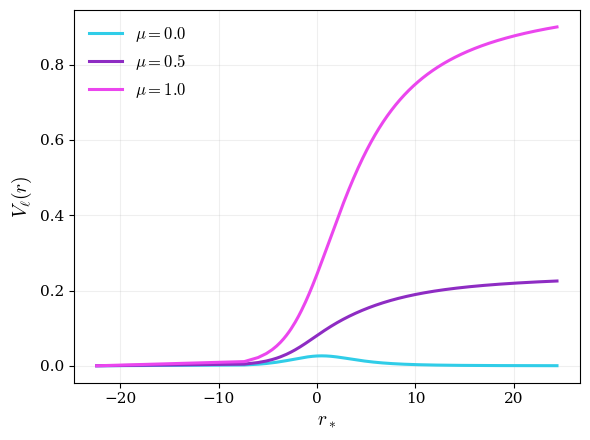

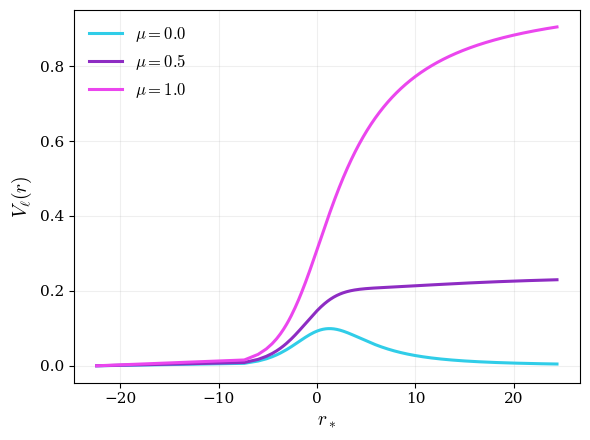

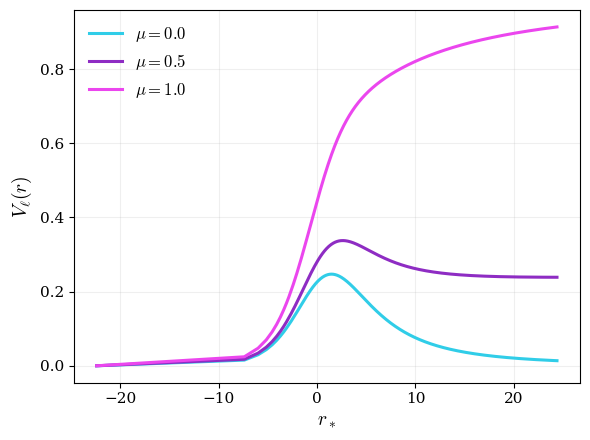

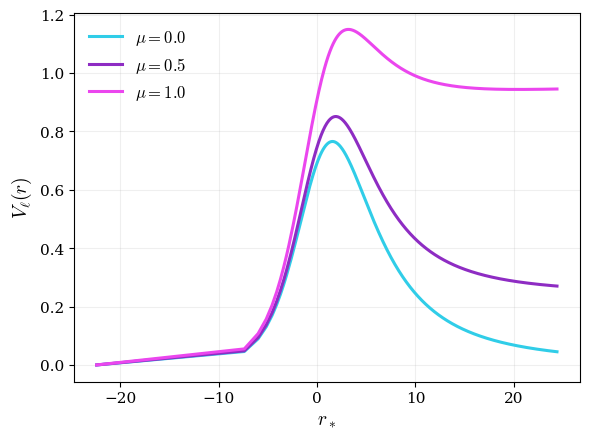

In [8]:
colores = ["#30CDE8", "#8E2CC3", "#EB46EE"]

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

for i, ell_val in enumerate(ell):

    fig, ax = plt.subplots(figsize=(6, 4.5))

    for j, mu_val in enumerate(mu):
        ax.plot(
            xs,
            Vplot[i, j, :],
            color=colores[j],
            linewidth=2.2,
            label=fr'$\mu={mu_val}$'
        )

    ax.set_xlabel(r'$r_*$', fontsize=14)
    ax.set_ylabel(r'$V_{\ell}(r)$', fontsize=14)

    ax.legend(fontsize=12, frameon=False)

    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()

    plt.savefig(
        f'V_ell_{ell_val}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fig)

In [9]:
mu = np.linspace(0,1,11)
ell = np.array([0, 1, 2])
Vplotqnm = np.zeros((len(ell), len(mu), len(x)))
for i in range(len(ell)):
    for j in range(len(mu)):
        Vplotqnm[i, j, :] = V(x, ell[i], mu[j])
Vplotqnm0 = np.zeros((len(ell), len(mu)))
alphaplotqnm0 = np.zeros((len(ell), len(mu)))
xplotqnm0 = np.zeros((len(ell), len(mu)))
indices = np.zeros((len(ell), len(mu)), dtype=int)
for i in range(len(ell)):
    for j in range(len(mu)):
        indices[i, j] = np.argmax(Vplotqnm[i, j, :])
        Vplotqnm0[i, j] = Vplotqnm[i, j, indices[i, j]]
        xplotqnm0[i, j] = x[indices[i, j]]
alphaplotqnm0 = np.sqrt(-1/(2*Vplotqnm0)*f(xplotqnm0)*(-4*M*mu[None, :]**2/xplotqnm0**3+(12*M**2*mu[None, :]**2+6*ell[:,None]*(ell[:,None]+1))/xplotqnm0**4+(24*M-40*M*ell[:,None]*(ell[:,None]+1))/xplotqnm0**5+(60*M**2*ell[:,None]*(ell[:,None]+1)-140*M**2)/xplotqnm0**6+192*M**3/xplotqnm0**7))

In [10]:
wr = np.zeros((len(ell), len(mu)))
wi = np.zeros((len(ell), len(mu)))
wr = (2*M)*np.sqrt(Vplotqnm0-alphaplotqnm0**2/4)
wi = (2*M)*alphaplotqnm0/2
print(wr)
print(wi)

[[0.22964008 0.26595881 0.36041544 0.56984064 0.75941087 0.94905144
  1.13872526 1.32841755 1.51812116 1.70783223 1.89754849]
 [0.59702834 0.60921251 0.64501745 0.70484033 0.79041779 0.95854274
  1.14663379 1.33519573 1.52405172 1.71310363 1.9022926 ]
 [0.97478502 0.98189386 1.00304048 1.03851261 1.08851872 1.15393112
  1.23616069 1.3486487  1.53584354 1.7235977  1.91174528]]
[[0.22963925 0.21237025 0.14917475 0.01347769 0.01396871 0.01419062
  0.01430982 0.01438126 0.01442744 0.01445903 0.01448159]
 [0.20149899 0.19575498 0.17989055 0.15076167 0.10190773 0.00978841
  0.01144355 0.01234342 0.01289731 0.01326522 0.01352299]
 [0.1955951  0.19308264 0.1868009  0.17564722 0.16003504 0.13799684
  0.1078853  0.00683172 0.00919966 0.01053442 0.01140062]]


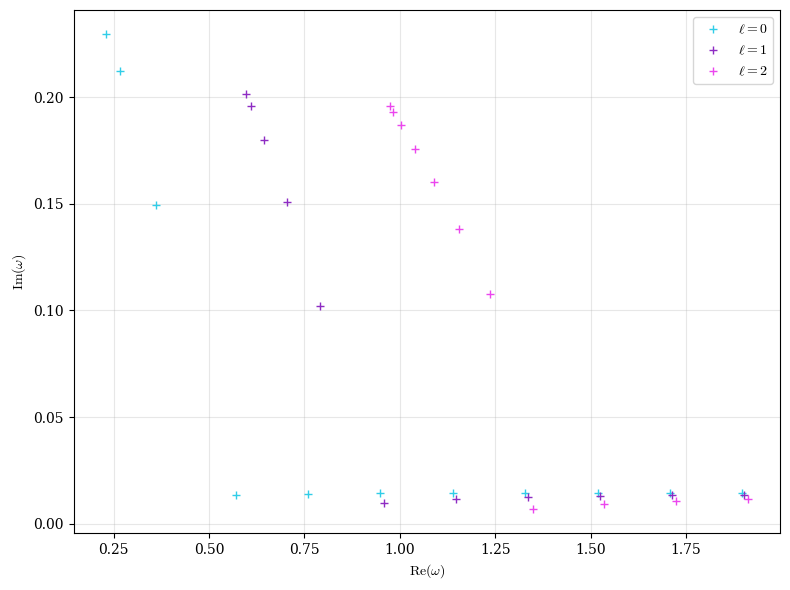

In [11]:
plt.figure(figsize=(8, 6))

for i, l in enumerate(ell):
    plt.plot(
        wr[i, :],
        wi[i, :],
        '+',
        color=colores[i],
        label=fr'$\ell={l}$'
    )

plt.xlabel(r'$\mathrm{Re}(\omega)$')
plt.ylabel(r'$\mathrm{Im}(\omega)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('PlotW.png', dpi=300, bbox_inches='tight')
plt.show()

Ahora calculamos la backreaction


In [51]:
A0 = 1
alpha0 = 0.05
ell = np.arange(0, 11)
mu = 0
Vbackreaction = np.zeros((len(ell), len(x)))
Vmax = np.zeros(len(ell))
indices = np.zeros(len(ell), dtype=int)
rmax = np.zeros(len(ell))
for i in range(len(ell)):
    Vbackreaction[i, :] = V(x, ell[i], mu)
    Vmax[i] = np.max(Vbackreaction[i, :])
    indices[i] = np.argmax(Vbackreaction[i, :])
    rmax[i] = x[indices[i]]
alphabackreaction = np.sqrt(-1/(2*Vmax)*f(rmax)*(-4*M*mu**2/rmax**3+(12*M**2*mu**2+6*ell*(ell+1))/rmax**4+(24*M-40*M*ell*(ell+1))/rmax**5+(60*M**2*ell*(ell+1)-140*M**2)/rmax**6+192*M**3/rmax**7))
omega_r = np.sqrt(Vmax-alphabackreaction**2/4)
omega_i = alphabackreaction/2
omega = omega_r - 1j*omega_i
beta = -1/2+1j*np.sqrt(-1/4+Vmax/alphabackreaction**2)
a = 1+beta+1j*omega/alphabackreaction
b = -beta+1j*omega/alphabackreaction
c = 1+1j*omega/alphabackreaction

In [52]:
def k(ell, s):
    return np.sqrt((2*ell+1)*mp.factorial(ell+s)/(2**(s+2)*np.pi*mp.factorial(ell-s)))

def coefE(s, sp, ell, ellp, m, mp, L):
    if abs(s) > ell or abs(sp) > ellp or abs(s+sp) > L:
        return 0
    if abs(m) > ell or abs(mp) > ellp or abs(m+mp) > L:
        return 0
    if L < abs(ell-ellp) or L > ell+ellp:
        return 0
    else:
        return k(ell, abs(s))*k(ellp, abs(sp))/k(L, abs(s+sp))*clebsch_gordan(ell, ellp, L, m, mp, m+mp)*clebsch_gordan(ell, ellp, L, s, sp, s+sp)

def xi(rs, ell):
    return 1/(1+np.exp(-2*alphabackreaction[ell]*(rs-rstar(rmax[ell]))))

def xiprime(rs, ell):
    return 2*alphabackreaction[ell]*np.exp(-2*alphabackreaction[ell]*(rs-rstar(rmax[ell])))/(1+np.exp(-2*alphabackreaction[ell]*(rs-rstar(rmax[ell]))))**2

def psi(rs, ell):
    return (xi(rs, ell)*(1-xi(rs, ell)))**(1j*omega[ell]/(2*alphabackreaction[ell]))*mp.hyp2f1(a[ell], b[ell], c[ell], xi(rs, ell))

def dR_dt(V, r, ell):
    return -1j*omega[ell]*psi(rstar(r), ell)/r*np.exp(-1j*omega[ell]*(V-rstar(r)))

def dR_dr(V, r, ell):
    return (np.exp(-1j*omega[ell]*(V-rstar(r)))*(-psi(rstar(r), ell)/r**2
        +1/r*1/f(r)*(1j*omega[ell]/(2*alphabackreaction[ell])*(xi(rstar(r), ell)-xi(rstar(r), ell)**2)**(1j*omega[ell]/(2*alphabackreaction[ell])-1)*(xiprime(rstar(r), ell)-2*xi(rstar(r), ell)*xiprime(rstar(r), ell))*mp.hyp2f1(a[ell], b[ell], c[ell], xi(rstar(r), ell))+
        a[ell]*b[ell]/c[ell]*(xi(rstar(r), ell)-xi(rstar(r), ell)**2)**(1j*omega[ell]/(2*alphabackreaction[ell]))*mp.hyp2f1(a[ell]+1, b[ell]+1, c[ell]+1, xi(rstar(r), ell))*xiprime(rstar(r), ell))))

def dR_dVef(V, r, ell):
    return dR_dt(V, r, ell)

def dR_dref(V, r, ell):
    return dR_dr(V, r, ell)-1/f(r)*dR_dt(V, r, ell)

def Integrando_ell(r, ell):
    term1 = np.conjugate(complex(omega[ell]*psi(rstar(r), ell)))*complex(omega[ell]*psi(rstar(r), ell))/(f(r)*r**2)
    derivadapsi_r = (-psi(rstar(r), ell)/r**2
        +1/(r*f(r))*(1j*omega[ell]/(2*alphabackreaction[ell])*(xi(rstar(r), ell)-xi(rstar(r), ell)**2)**(1j*omega[ell]/(2*alphabackreaction[ell])-1)*(xiprime(rstar(r), ell)-2*xi(rstar(r), ell)*xiprime(rstar(r), ell))*mp.hyp2f1(a[ell], b[ell], c[ell], xi(rstar(r), ell))+
        a[ell]*b[ell]/c[ell]*(xi(rstar(r), ell)-xi(rstar(r), ell)**2)**(1j*omega[ell]/(2*alphabackreaction[ell]))*mp.hyp2f1(a[ell]+1, b[ell]+1, c[ell]+1, xi(rstar(r), ell))*xiprime(rstar(r), ell)))
    term2 = f(r)*np.conjugate(complex(derivadapsi_r))*complex(derivadapsi_r)
    term3 = (ell*(ell+1)/r**2+mu**2)*np.conjugate(complex(psi(rstar(r), ell)))*complex(psi(rstar(r), ell))
    return term1+term2+term3

Normalizamos el campo.

In [65]:
Energia = 1e-3*M
rminimo = 2.00001
rmaximo = 50
intervalos = 100
deltar = (rmaximo-rminimo)/intervalos
integral_ell = np.zeros(len(ell),dtype=complex)
suma = 0
for i in range(len(ell)):
    integral_ell[i] = rminimo**2*Integrando_ell(rminimo, ell[i])+rmaximo**2*Integrando_ell(rmaximo, ell[i])
    for j in range(1,intervalos):
        r = rminimo+j*deltar
        integral_ell[i] += 2*r**2*Integrando_ell(r, ell[i])
    suma += (2*ell[i]+1)*integral_ell[i]*deltar/2*np.exp(-2*alpha0*(ell[i]*(ell[i]+1)))
A0 = np.real(np.sqrt(Energia/suma))

In [66]:
def A(ell):
    return A0*np.exp(-alpha0*ell*(ell+1))

def QVVell(V, r, ell):
    aux = 0
    A_ell = A(ell)
    derivadarsch = complex(dR_dr(V, r, ell))
    derivadatsch = complex(dR_dt(V, r, ell))
    derivadaVef = complex(dR_dVef(V, r, ell))
    R = complex(psi(rstar(r), ell)/r*np.exp(-1j*omega[ell]*(V-rstar(r))))
    for m in range(-ell, ell+1):
        aux += ((-1)**m*(2*(np.conjugate(derivadaVef)*derivadaVef))*coefE(0, 0, ell, ell, m, -m, 0)+
            f(r)*(-np.conjugate(R)*R*coefE(1, -1, ell, ell, -m, m, 0)+
            (-1/f(r)*np.conjugate(derivadatsch)*derivadatsch+f(r)*np.conjugate(derivadarsch)*derivadarsch+mu**2*np.conjugate(R)*R)*coefE(0, 0, ell, ell, -m, m, 0)))
    return np.real(8*np.pi*aux*A_ell**2)

def QVrell(V, r, ell):
    aux = 0
    A_ell = A(ell)
    derivadarsch = complex(dR_dr(V, r, ell))
    derivadatsch = complex(dR_dt(V, r, ell))
    derivadaVef = complex(dR_dVef(V, r, ell))
    derivadaref = complex(dR_dref(V, r, ell))
    R = complex(psi(rstar(r), ell)/r*np.exp(-1j*omega[ell]*(V-rstar(r))))
    for m in range(-ell, ell+1):
        aux += ((-1)**m*((np.conjugate(derivadaVef)*derivadaref)+np.conjugate(derivadaref)*derivadaVef)*coefE(0, 0, ell, ell, m, -m, 0)-
            (-np.conjugate(R)*R*coefE(1, -1, ell, ell, -m, m, 0)+
            (-1/f(r)*np.conjugate(derivadatsch)*derivadatsch+f(r)*np.conjugate(derivadarsch)*derivadarsch+mu**2*np.conjugate(R)*R)*coefE(0, 0, ell, ell, -m, m, 0)))
    return np.real(8*np.pi*aux*A_ell**2)

def Qrrell(V, r, ell):
    aux = 0
    A_ell = A(ell)
    derivadaref = complex(dR_dref(V, r, ell))
    R = complex(psi(rstar(r), ell)/r*np.exp(-1j*omega[ell]*(V-rstar(r))))
    for m in range(-ell, ell+1):
        aux += (-1)**m*(2*(np.conjugate(derivadaref)*derivadaref)*coefE(0, 0, ell, ell, m, -m, 0))
    return np.real(8*np.pi*aux*A_ell**2)

Hacemos las tres integrales para cada $\ell$.

In [ ]:
Vminimo = 0
Vmaximo = 100
integralesr2QVr = np.zeros(len(ell), dtype=complex)
integralesrQrr = np.zeros(len(ell), dtype=complex)
for i in range(len(ell)):
    integralesr2QVr[i] = (rminimo**2*QVrell(10, rminimo, ell[i])+rmaximo**2*QVrell(10, rmaximo, ell[i]))
    integralesrQrr[i] = (rminimo*Qrrell(10, rminimo, ell[i])+rmaximo*Qrrell(10, rmaximo, ell[i]))
    for j in range(1,intervalos):
        r = rminimo+j*deltar
        integralesr2QVr[i] += 2*r**2*QVrell(10, r, ell[i])
        integralesrQrr[i] += 2*r*Qrrell(10, r, ell[i])
integralesr2QVr = np.real(integralesr2QVr*deltar/2)
integralesrQrr = np.real(integralesrQrr*deltar/2)
print(integralesr2QVr)
print(integralesrQrr)

[-0.23041216 -0.04322208 -0.85403615 -0.52977285 -1.35169196 -0.57916415
 -0.59039467 -0.16239494 -0.08143986 -0.01465736 -0.00410063]
[0.01005394 0.00987783 0.02368179 0.0414694  0.04416178 0.03581475
 0.02089524 0.00909276 0.00301968 0.00077721 0.00015673]


In [ ]:
intervalos = 50
deltar = (rmaximo-rminimo)/intervalos
deltaV = (Vmaximo-Vminimo)/intervalos
integralcuadradaV = np.zeros((intervalos+1, intervalos+1, len(ell)))
for i in range(len(ell)):
    for jr in range(intervalos+1):
        r = rminimo+jr*deltar
        for jV in range(1,intervalos+1):
            V = Vminimo+jV*deltaV
            integralcuadradaV[jr, jV, i] = integralcuadradaV[jr, jV-1, i]+(QVVell(V-deltaV, r, ell[i])+QVVell(V, r, ell[i])+f(r)*(QVrell(r-deltar, V, ell[i])+QVrell(r, V, ell[i])))*deltaV/2

